In [24]:
import sys
sys.executable

'C:\\Users\\user\\AppData\\Local\\Python\\pythoncore-3.14-64\\python.exe'

# **<u>Business Challenge: EDA and SQL</u>**

## **1. <u>Business questions (around 10)</u>**
Here’s a coherent set that matches your columns and the sample questions:

1. ### **Screen time & mental wellness:**  
**Q1.** How does total daily `screen_time_hours` relate to `mental_wellness_index_0_100` overall?

2. ### **Anxiety/stress angle:**  
**Q2.** Is higher `screen_time_hours` associated with higher `stress_level_0_10`?

3. ### **Work vs leisure screen time:**  
**Q3.** Does the balance between `work_screen_hours` and `leisure_screen_hours` impact `mental_wellness_index_0_100` differently?

4. ### **Sleep as a mediator:**  
**Q4.** Do participants with similar screen time but different `sleep_hours` show different `mental_wellness_index_0_100`?

5. ### **Sleep quality & stress:** 
**Q5.** How does `sleep_quality_1_5` relate to `stress_level_0_10` and `mental_wellness_index_0_100`?

6. ### **Productivity vs screen time:** 
**Q6.** Is there an optimal range of `screen_time_hours` associated with higher `productivity_0_100`?

7. ### **Exercise & wellness:**
**Q7.** Do participants with higher `exercise_minutes_per_week` show better `mental_wellness_index_0_100` at similar screen time levels?

8. ### **Social time & wellness:**
**Q8.** How does `social_hours_per_week` relate to `mental_wellness_index_0_100` and `stress_level_0_10`?

9. ### **Demographics (age & gender):**
**Q9.** Are there notable differences in `screen_time_hours` and `mental_wellness_index_0_100` across age groups and gender?

10. ### **Work mode differences:**  
**Q10.** Do `work_mode` categories (Remote/Hybrid/In-person) differ in average `screen_time_hours`, `sleep_hours`, and `mental_wellness_index_0_100`?

## **2. <u>Python code: EDA + SQL upload</u>**

1. ### **Imports**

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.0)

In [26]:
# !pip install ipython-sql
# !pip install prettytable==3.7.0

 2. ### **Load data for both EDA and SQL**

In [27]:
df = pd.read_csv("ScreenTime_vs_MentalWellness.csv")

#### Quick peek

In [28]:
df.shape

(400, 16)

In [29]:
df.head()

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3,NaN
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2,NaN
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6,NaN
3,U0004,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0,NaN
4,U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0,NaN


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      400 non-null    str    
 1   age                          400 non-null    int64  
 2   gender                       400 non-null    str    
 3   occupation                   400 non-null    str    
 4   work_mode                    400 non-null    str    
 5   screen_time_hours            400 non-null    float64
 6   work_screen_hours            400 non-null    float64
 7   leisure_screen_hours         400 non-null    float64
 8   sleep_hours                  400 non-null    float64
 9   sleep_quality_1_5            400 non-null    int64  
 10  stress_level_0_10            400 non-null    float64
 11  productivity_0_100           400 non-null    float64
 12  exercise_minutes_per_week    400 non-null    int64  
 13  social_hours_per_week        40

3. ### **Basic cleaning**

#### Drop unnamed column if present

In [31]:
unnamed_cols = [c for c in df.columns if c.lower().startswith("unnamed")]
df = df.drop(columns=unnamed_cols)

In [32]:
df.head()

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6
3,U0004,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0
4,U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0


#### Standardize column names if needed (already clean here)

In [33]:
df.columns = [c.strip() for c in df.columns]

In [34]:
df.head()

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6
3,U0004,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0
4,U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0


#### Check missing values & duplicates

In [35]:
print("\nMissing values per column:")
print(df.isna().sum())

print("\nDuplicate user_id:", df["user_id"].duplicated().sum())


Missing values per column:
user_id                        0
age                            0
gender                         0
occupation                     0
work_mode                      0
screen_time_hours              0
work_screen_hours              0
leisure_screen_hours           0
sleep_hours                    0
sleep_quality_1_5              0
stress_level_0_10              0
productivity_0_100             0
exercise_minutes_per_week      0
social_hours_per_week          0
mental_wellness_index_0_100    0
dtype: int64

Duplicate user_id: 0


 4. ### **Descriptive statistics**

In [36]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

C:\Users\user\AppData\Local\Temp\ipykernel_8988\1919383789.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


In [37]:
print("\nNumeric summary:")
df[num_cols].describe().T


Numeric summary:


,count,mean,std,min,25%,50%,75%,max
age,400.0,29.777500,7.466080,16.00,24.0000,30.000,35.0000,60.00
screen_time_hours,400.0,9.024900,2.491058,1.00,7.3725,9.090,10.4950,19.17
work_screen_hours,400.0,2.183075,1.931321,0.11,0.6950,1.455,3.0125,12.04
leisure_screen_hours,400.0,6.841825,2.220896,0.89,5.4600,6.700,8.4175,13.35
sleep_hours,400.0,7.013175,0.852421,4.64,6.3975,7.030,7.6400,9.74
sleep_quality_1_5,400.0,1.397500,0.652348,1.00,1.0000,1.000,2.0000,4.00
stress_level_0_10,400.0,8.150500,2.094844,0.00,6.9000,8.800,10.0000,10.00
productivity_0_100,400.0,54.306500,15.020054,20.60,43.6000,51.750,63.0000,100.00
exercise_minutes_per_week,400.0,109.810000,70.007045,0.00,58.0000,103.000,157.0000,372.00
social_hours_per_week,400.0,7.905000,4.909632,0.00,4.5750,7.750,11.0250,23.90


In [38]:
print("\nCategorical summary:")
df[cat_cols].describe().T


Categorical summary:


,count,unique,top,freq
user_id,400,400,U0001,1
gender,400,3,Female,222
occupation,400,5,Employed,207
work_mode,400,3,Remote,150


In [39]:
print("\nCategorical value counts:")
for c in cat_cols:
    print(f"\n{c}:")
    print(df[c].value_counts())


Categorical value counts:

user_id:
user_id
U0001    1
U0002    1
U0003    1
U0004    1
U0005    1
        ..
U0396    1
U0397    1
U0398    1
U0399    1
U0400    1
Name: count, Length: 400, dtype: int64

gender:
gender
Female              222
Male                170
Non-binary/Other      8
Name: count, dtype: int64

occupation:
occupation
Employed         207
Student          107
Self-employed     45
Unemployed        27
Retired           14
Name: count, dtype: int64

work_mode:
work_mode
Remote       150
Hybrid       146
In-person    104
Name: count, dtype: int64


5. ### **Univariate distributions**

In [40]:
num_cols

Index(['age', 'screen_time_hours', 'work_screen_hours', 'leisure_screen_hours',
       'sleep_hours', 'sleep_quality_1_5', 'stress_level_0_10',
       'productivity_0_100', 'exercise_minutes_per_week',
       'social_hours_per_week', 'mental_wellness_index_0_100'],
      dtype='str')

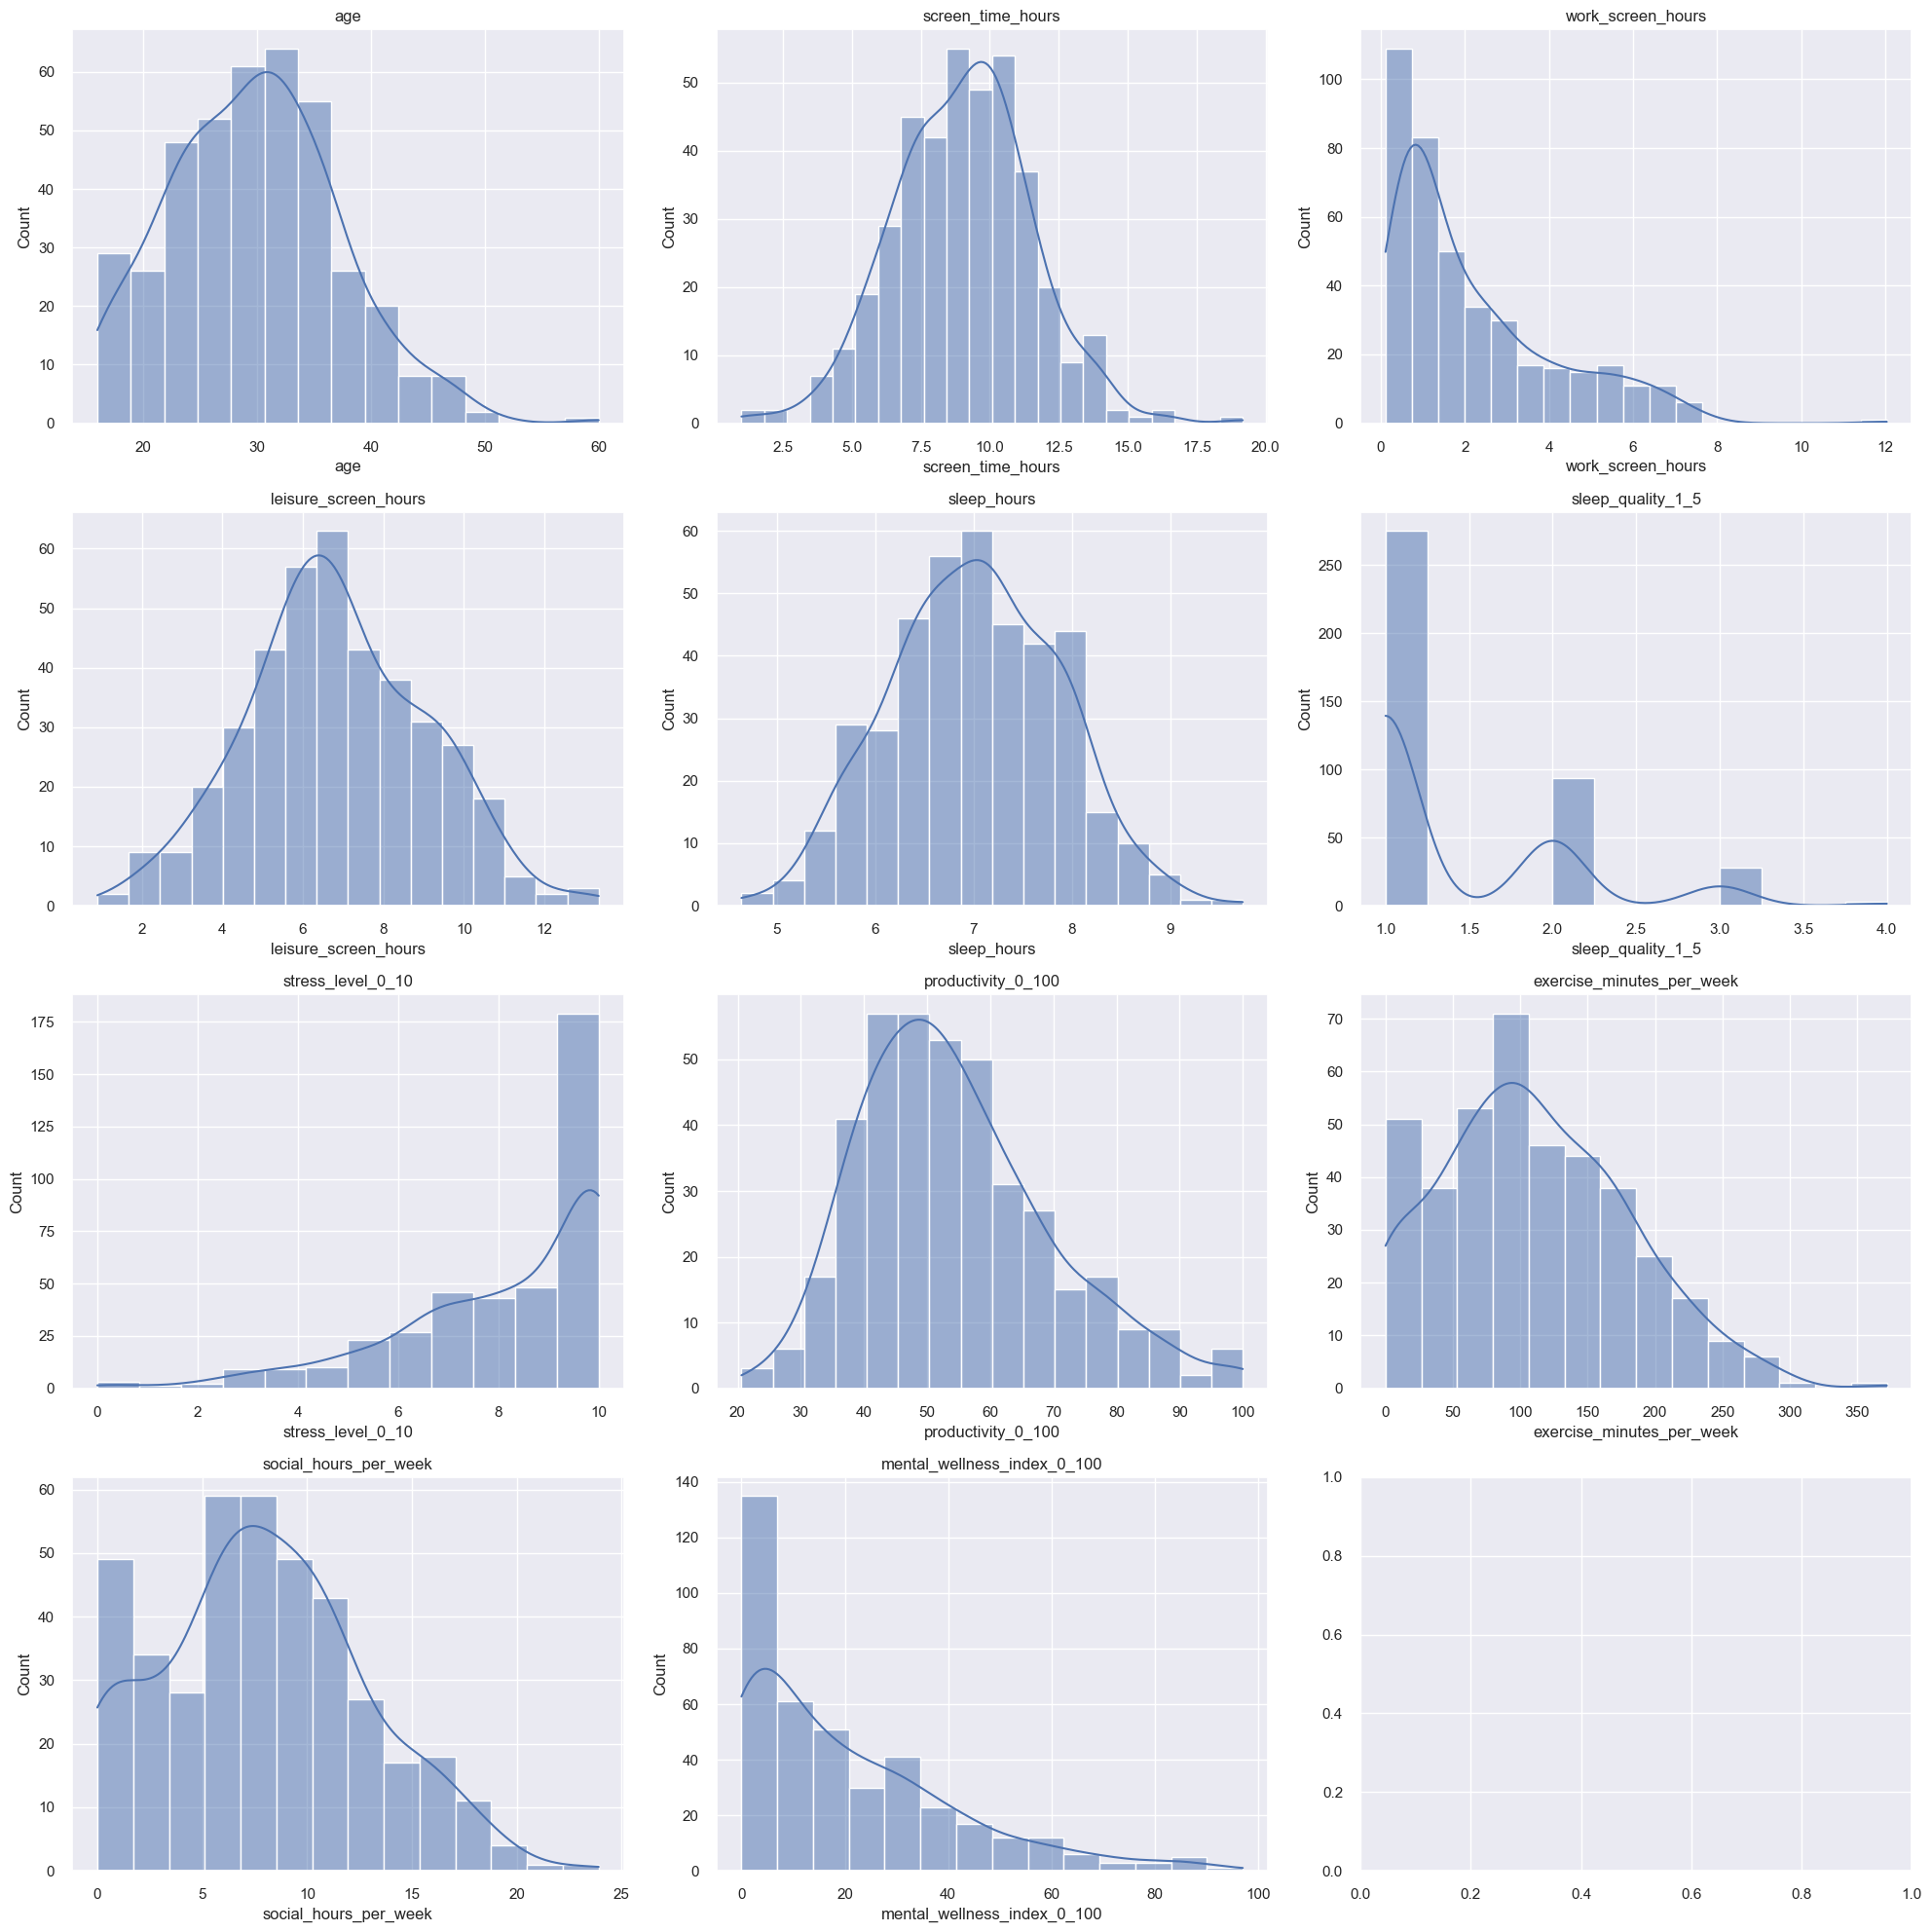

In [41]:
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
axes = axes.flatten()
plot_cols = [
    "age",
    "screen_time_hours",
    "work_screen_hours",
    "leisure_screen_hours",
    "sleep_hours",
    "sleep_quality_1_5",
    "stress_level_0_10",
    "productivity_0_100",
    "exercise_minutes_per_week",
    "social_hours_per_week",
    "mental_wellness_index_0_100"
]

for ax, col in zip(axes, plot_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

6. ### **Correlation analysis**

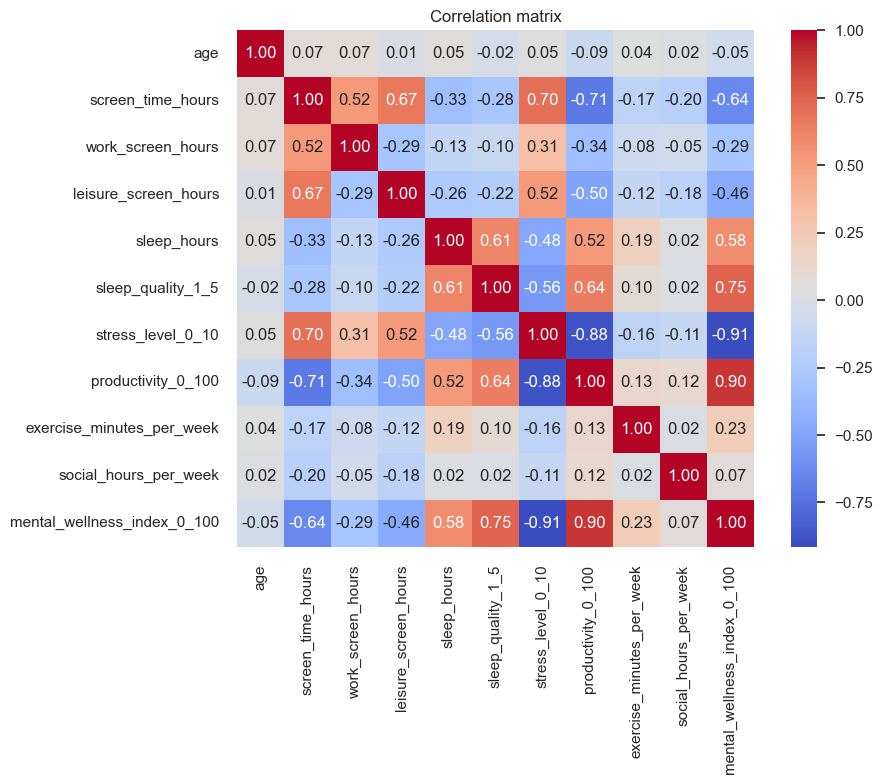

In [42]:
corr_cols = [
    "age",
    "screen_time_hours",
    "work_screen_hours",
    "leisure_screen_hours",
    "sleep_hours",
    "sleep_quality_1_5",
    "stress_level_0_10",
    "productivity_0_100",
    "exercise_minutes_per_week",
    "social_hours_per_week",
    "mental_wellness_index_0_100"
]

corr = df[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

7. ### **Some EDA plots aligned with business questions**

#### Q1 & Q2 — Screen time vs wellness & stress

##### **Q1.** How does total daily `screen_time_hours` relate to `mental_wellness_index_0_100` overall?

##### **Q2.** Is higher `screen_time_hours` associated with higher `stress_level_0_10`?

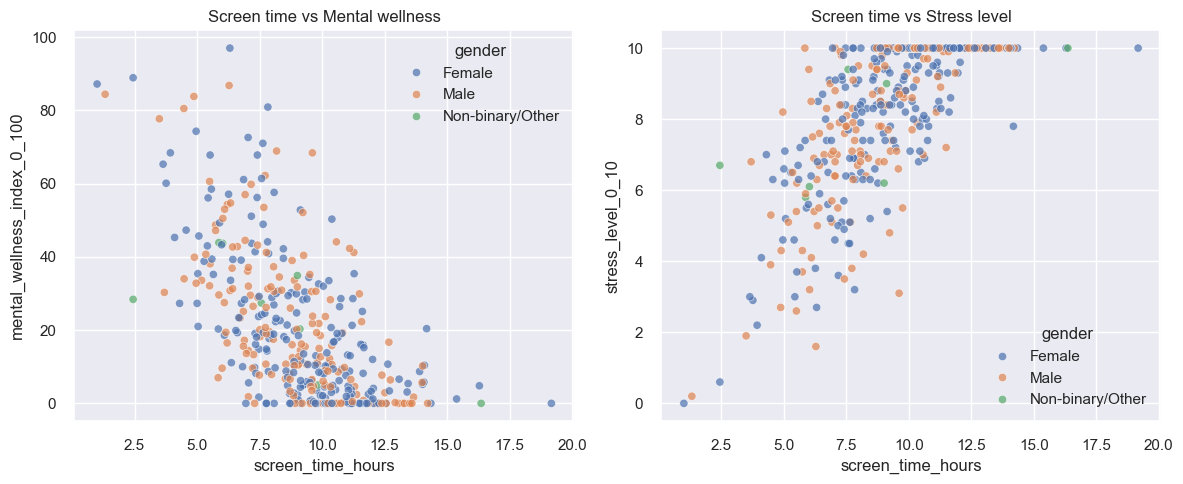

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(
    data=df,
    x="screen_time_hours",
    y="mental_wellness_index_0_100",
    hue="gender",
    alpha=0.7,
    ax=axes[0],
)
axes[0].set_title("Screen time vs Mental wellness")

sns.scatterplot(
    data=df,
    x="screen_time_hours",
    y="stress_level_0_10",
    hue="gender",
    alpha=0.7,
    ax=axes[1],
)
axes[1].set_title("Screen time vs Stress level")
plt.tight_layout()
plt.show()

#### Q3 — Work vs Leisure Screen Time

##### Does the balance between work and leisure screen time matter?

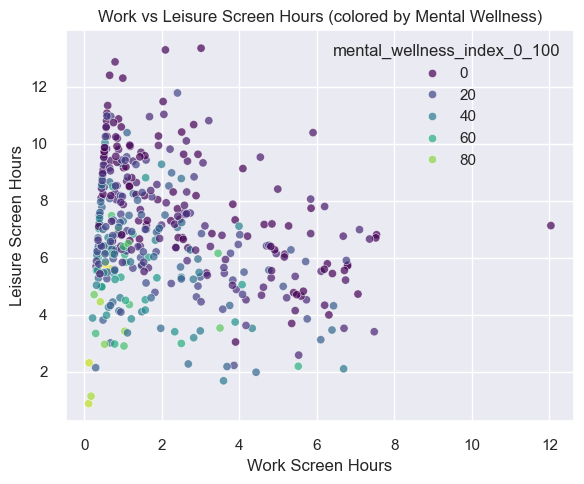

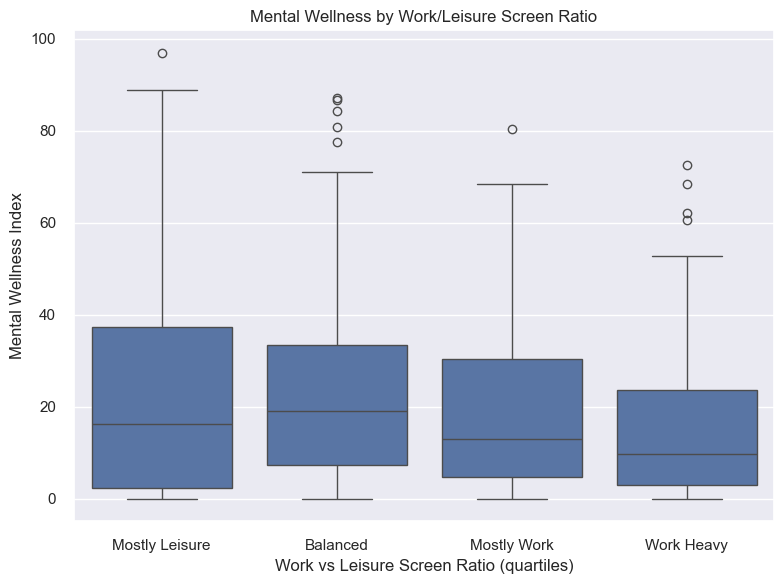

In [44]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x="work_screen_hours",
    y="leisure_screen_hours",
    hue="mental_wellness_index_0_100",
    palette="viridis",
    alpha=0.7
)
plt.title("Work vs Leisure Screen Hours (colored by Mental Wellness)")
plt.xlabel("Work Screen Hours")
plt.ylabel("Leisure Screen Hours")
plt.tight_layout()
plt.show()

# Ratio plot
df["work_leisure_ratio"] = df["work_screen_hours"] / (df["leisure_screen_hours"] + 0.1)

plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x=pd.qcut(df["work_leisure_ratio"], q=4, labels=["Mostly Leisure","Balanced","Mostly Work","Work Heavy"]),
    y="mental_wellness_index_0_100"
)
plt.title("Mental Wellness by Work/Leisure Screen Ratio")
plt.xlabel("Work vs Leisure Screen Ratio (quartiles)")
plt.ylabel("Mental Wellness Index")
plt.tight_layout()
plt.show()


#### Q4 & Q5 — Sleep hours/quality vs wellness

##### **Q4.** Do participants with similar screen time but different `sleep_hours` show different `mental_wellness_index_0_100`?

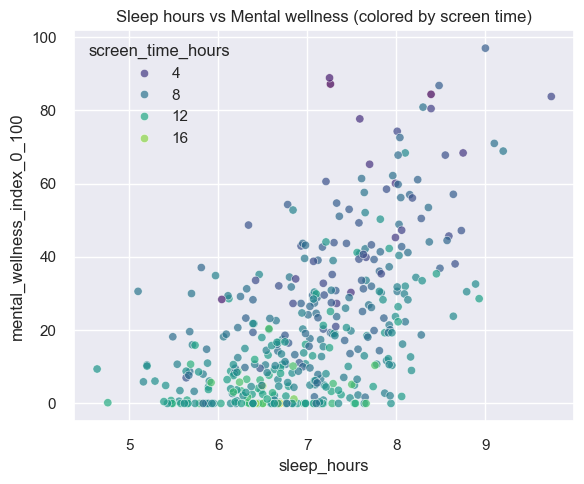

In [45]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="sleep_hours",
    y="mental_wellness_index_0_100",
    hue="screen_time_hours",
    palette="viridis",
    alpha=0.7,
)
plt.title("Sleep hours vs Mental wellness (colored by screen time)")
plt.tight_layout()
plt.show()

##### **Q5.** How does `sleep_quality_1_5` relate to `stress_level_0_10` and `mental_wellness_index_0_100`?

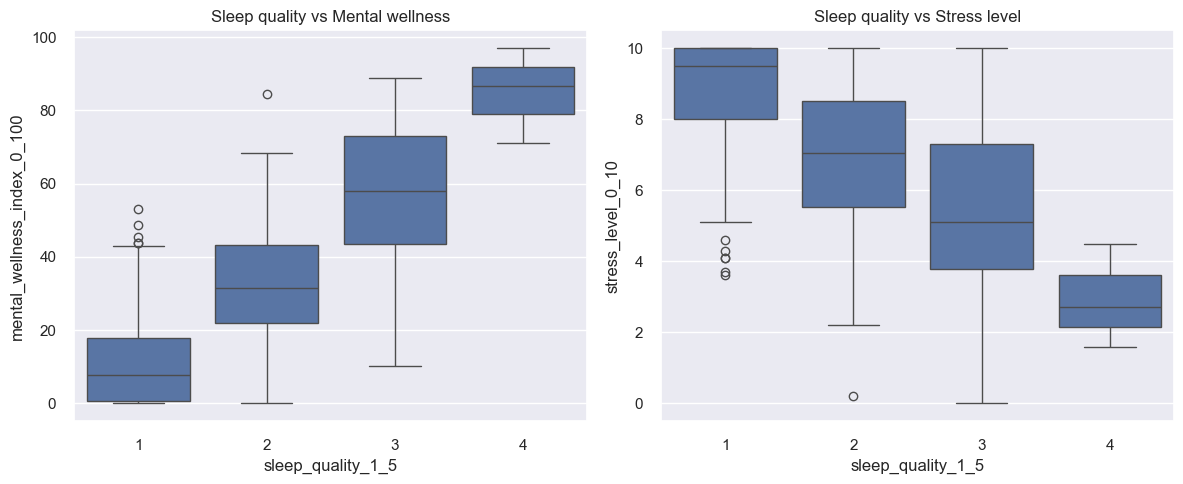

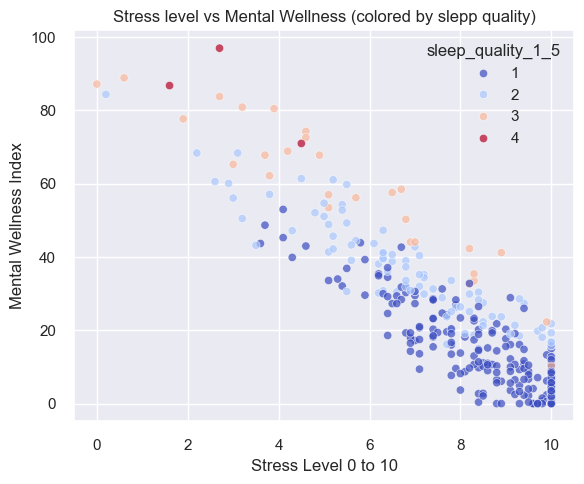

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=df,
    x="sleep_quality_1_5",
    y="mental_wellness_index_0_100",
    ax=axes[0]
)
axes[0].set_title("Sleep quality vs Mental wellness")

sns.boxplot(
    data=df,
    x="sleep_quality_1_5",
    y="stress_level_0_10",
    ax=axes[1]
)
axes[1].set_title("Sleep quality vs Stress level")

plt.tight_layout()
plt.show()


# Bivariate analysis

plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x="stress_level_0_10",
    y="mental_wellness_index_0_100",
    hue="sleep_quality_1_5",
    palette="coolwarm",
    alpha=0.7
)
plt.title("Stress level vs Mental Wellness (colored by slepp quality)")
plt.xlabel("Stress Level 0 to 10")
plt.ylabel("Mental Wellness Index")
plt.tight_layout()
plt.show()

#### Q6 — Productivity vs Screen Time

##### Is there an optimal screen time range for productivity?

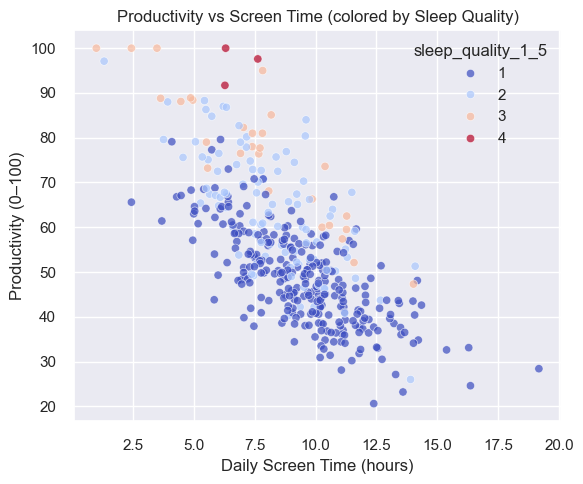

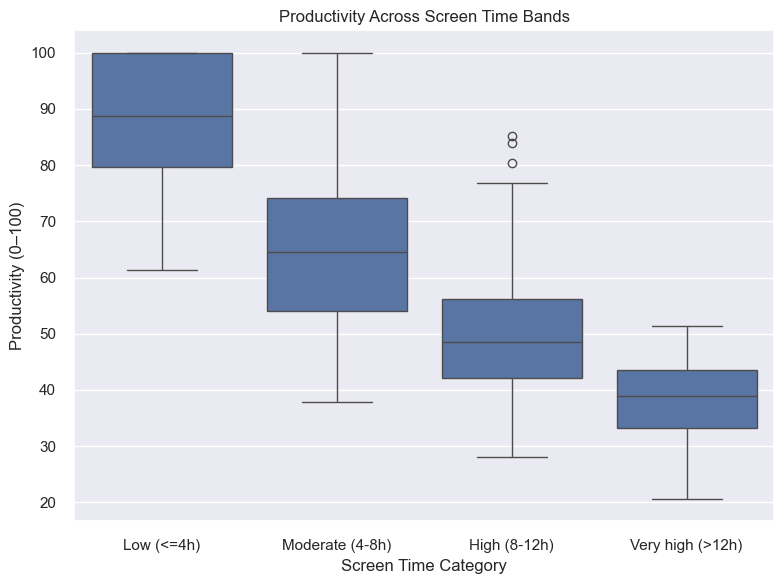

In [50]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x="screen_time_hours",
    y="productivity_0_100",
    hue="sleep_quality_1_5",
    palette="coolwarm",
    alpha=0.7
)
plt.title("Productivity vs Screen Time (colored by Sleep Quality)")
plt.xlabel("Daily Screen Time (hours)")
plt.ylabel("Productivity (0–100)")
plt.tight_layout()
plt.show()

# Screen time bands
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x="screen_time_band",
    y="productivity_0_100",
    order=["Low (<=4h)", "Moderate (4-8h)", "High (8-12h)", "Very high (>12h)"]
)
plt.title("Productivity Across Screen Time Bands")
plt.xlabel("Screen Time Category")
plt.ylabel("Productivity (0–100)")
plt.tight_layout()
plt.show()


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   user_id                      400 non-null    str     
 1   age                          400 non-null    int64   
 2   gender                       400 non-null    str     
 3   occupation                   400 non-null    str     
 4   work_mode                    400 non-null    str     
 5   screen_time_hours            400 non-null    float64 
 6   work_screen_hours            400 non-null    float64 
 7   leisure_screen_hours         400 non-null    float64 
 8   sleep_hours                  400 non-null    float64 
 9   sleep_quality_1_5            400 non-null    int64   
 10  stress_level_0_10            400 non-null    float64 
 11  productivity_0_100           400 non-null    float64 
 12  exercise_minutes_per_week    400 non-null    int64   
 13  social_hours_per

#### Q7 — Exercise & Wellness

##### Does exercise buffer the negative effects of screen time?

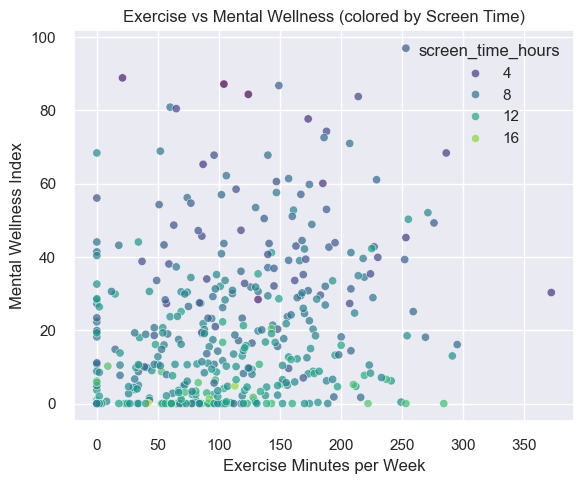

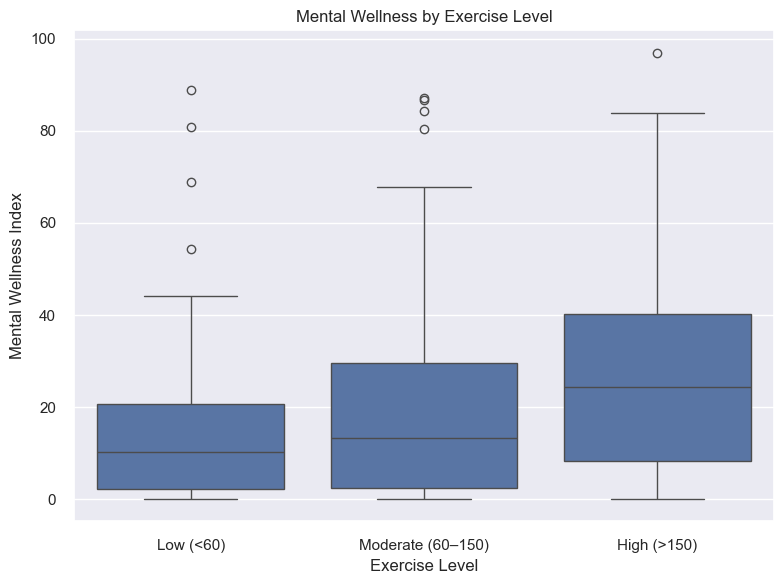

In [52]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x="exercise_minutes_per_week",
    y="mental_wellness_index_0_100",
    hue="screen_time_hours",
    palette="viridis",
    alpha=0.7
)
plt.title("Exercise vs Mental Wellness (colored by Screen Time)")
plt.xlabel("Exercise Minutes per Week")
plt.ylabel("Mental Wellness Index")
plt.tight_layout()
plt.show()

# Exercise bands
df["exercise_band"] = pd.cut(
    df["exercise_minutes_per_week"],
    bins=[0, 60, 150, df["exercise_minutes_per_week"].max()],
    labels=["Low (<60)", "Moderate (60–150)", "High (>150)"]
)

plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x="exercise_band",
    y="mental_wellness_index_0_100",
    order=["Low (<60)", "Moderate (60–150)", "High (>150)"]
)
plt.title("Mental Wellness by Exercise Level")
plt.xlabel("Exercise Level")
plt.ylabel("Mental Wellness Index")
plt.tight_layout()
plt.show()


#### Q8 — Social Time & Wellness

##### Does social interaction improve mental wellness?

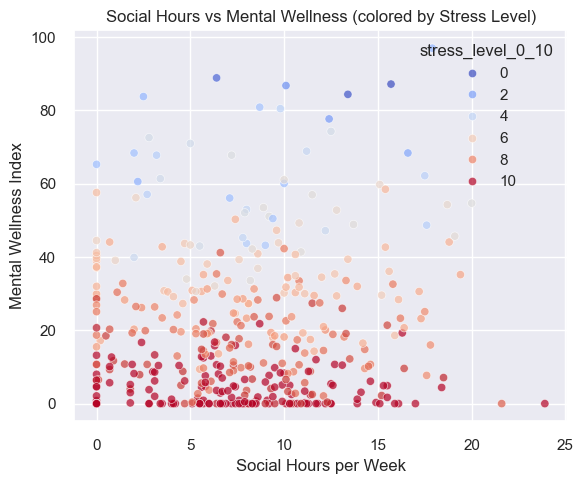

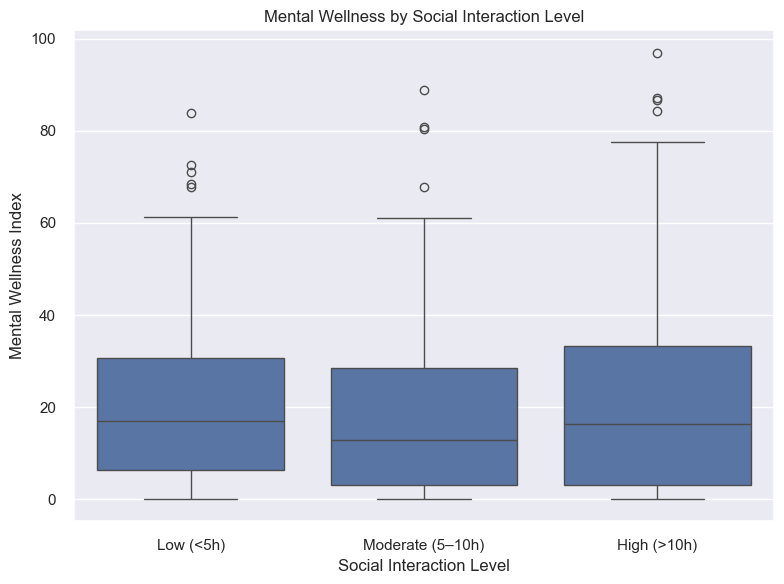

In [54]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x="social_hours_per_week",
    y="mental_wellness_index_0_100",
    hue="stress_level_0_10",
    palette="coolwarm",
    alpha=0.7
)
plt.title("Social Hours vs Mental Wellness (colored by Stress Level)")
plt.xlabel("Social Hours per Week")
plt.ylabel("Mental Wellness Index")
plt.tight_layout()
plt.show()

# Social bands
df["social_time_band"] = pd.cut(
    df["social_hours_per_week"],
    bins=[0, 5, 10, df["social_hours_per_week"].max()],
    labels=["Low (<5h)", "Moderate (5–10h)", "High (>10h)"]
)

plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x="social_time_band",
    y="mental_wellness_index_0_100",
    order=["Low (<5h)", "Moderate (5–10h)", "High (>10h)"]
)
plt.title("Mental Wellness by Social Interaction Level")
plt.xlabel("Social Interaction Level")
plt.ylabel("Mental Wellness Index")
plt.tight_layout()
plt.show()


#### Q9 & Q10 — Demographics and work mode

##### **Q9.** Are there notable differences in `screen_time_hours` and `mental_wellness_index_0_100` across age groups and gender?

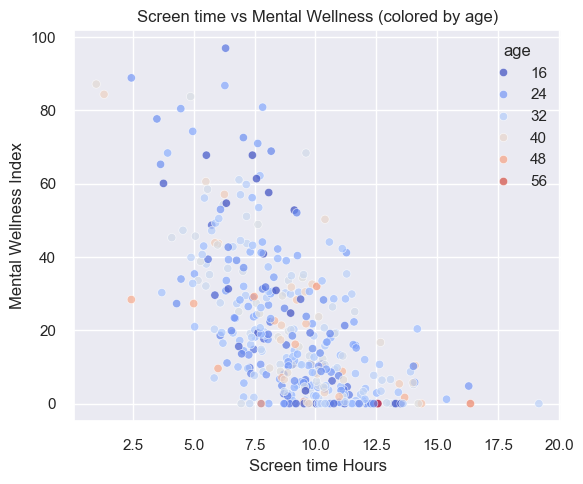

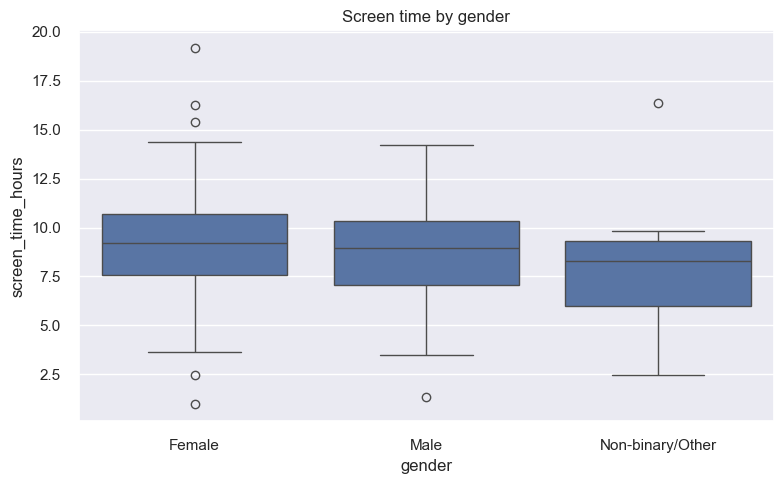

In [57]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x="screen_time_hours",
    y="mental_wellness_index_0_100",
    hue="age",
    palette="coolwarm",
    alpha=0.7
)
plt.title("Screen time vs Mental Wellness (colored by age)")
plt.xlabel("Screen time Hours")
plt.ylabel("Mental Wellness Index")
plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="gender",
    y="screen_time_hours",
)
plt.title("Screen time by gender")
plt.tight_layout()
plt.show()

**Q10.** Do `work_mode` categories (Remote/Hybrid/In-person) differ in average `screen_time_hours`, `sleep_hours`, and `mental_wellness_index_0_100`?

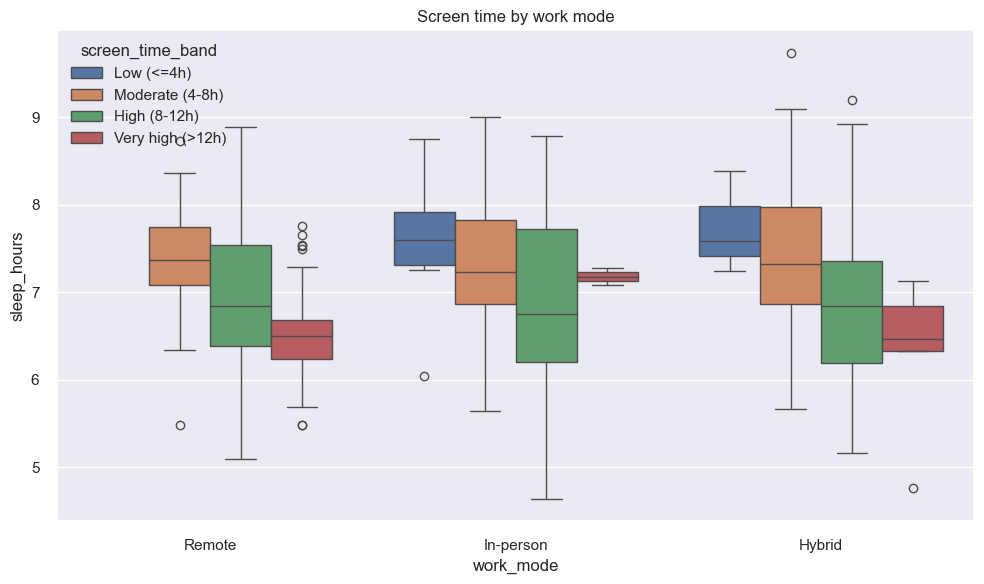

In [63]:



plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="work_mode",
    y="sleep_hours",
    hue="screen_time_band"
)
plt.title("Screen time by work mode")
plt.tight_layout()
plt.show()

8. ### (Optional) Feature engineering for reporting
#### Example: categorize screen time

In [48]:
bins = [0, 4, 8, 12, np.inf]
labels = ["Low (<=4h)", "Moderate (4-8h)", "High (8-12h)", "Very high (>12h)"]
df["screen_time_band"] = pd.cut(df["screen_time_hours"], bins=bins, labels=labels)

In [49]:
df.head()

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,work_leisure_ratio,screen_time_band
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3,0.998165,High (8-12h)
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2,0.051893,Moderate (4-8h)
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6,0.124005,High (8-12h)
3,U0004,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0,0.052484,High (8-12h)
4,U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0,0.443120,Very high (>12h)


9. ### **Upload to SQL (example with SQLite; change URL for Postgres/MySQL)**

In [288]:
engine = create_engine("sqlite:///mydb.db")

#### Write table

In [289]:
df.to_sql("ScreenTime_vs_MentalWellness", engine, if_exists="replace", index=False)

400

In [290]:
%sql sqlite:///mydb.db

In [291]:
%load_ext sql

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [293]:
%%sql
SELECT * FROM ScreenTime_vs_MentalWellness LIMIT 5;

 * sqlite:///mydb.db
Done.


user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,work_leisure_ratio,exercise_band,screen_time_band,social_time_band
U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3,0.9981651376146791,Moderate (60–150),High (8-12h),Low (<5h)
U0002,28,Female,Employed,In-person,7.4,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2,0.051893408134642355,Moderate (60–150),Moderate (4-8h),Low (<5h)
U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6,0.12400455062571106,Moderate (60–150),High (8-12h),Moderate (5–10h)
U0004,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0,0.05248359887535146,None,High (8-12h),Moderate (5–10h)
U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0,0.44312026002166843,Moderate (60–150),Very high (>12h),High (>10h)


In [294]:
print("Data uploaded to SQL database 'mydb.db', table 'ScreenTime_vs_MentalWellness'.")

Data uploaded to SQL database 'mydb.db', table 'ScreenTime_vs_MentalWellness'.


## 3. **<u>SQL file: schema + queries for the 10 questions</u>**

1. ### **Table creation (if you need it in the .sql file)**

In [295]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   user_id                      400 non-null    str     
 1   age                          400 non-null    int64   
 2   gender                       400 non-null    str     
 3   occupation                   400 non-null    str     
 4   work_mode                    400 non-null    str     
 5   screen_time_hours            400 non-null    float64 
 6   work_screen_hours            400 non-null    float64 
 7   leisure_screen_hours         400 non-null    float64 
 8   sleep_hours                  400 non-null    float64 
 9   sleep_quality_1_5            400 non-null    int64   
 10  stress_level_0_10            400 non-null    float64 
 11  productivity_0_100           400 non-null    float64 
 12  exercise_minutes_per_week    400 non-null    int64   
 13  social_hours_per

In [296]:
%%sql 

-- Schema (SQLite / generic SQL style)
CREATE TABLE IF NOT EXISTS ScreenTime_vs_MentalWellness (
    user_id TEXT PRIMARY KEY,
    age INT,
    gender TEXT,
    occupation TEXT,
    work_mode TEXT,
    screen_time_hours REAL,
    work_screen_hours REAL,
    leisure_screen_hours REAL,
    sleep_hours REAL,
    sleep_quality_1_5 INT,
    stress_level_0_10 REAL,
    productivity_0_100 REAL,
    exercise_minutes_per_week INT,
    social_hours_per_week REAL,
    mental_wellness_index_0_100 REAL,
    screen_time_band TEXT,
    work_leisure_ratio REAL,
    exercise_band TEXT,
    social_time_band TEX
);


 * sqlite:///mydb.db
Done.


[]

2. ### **Queries answering each business question**

#### **Screen time & mental wellness:**
##### Q1: How does total daily `screen_time_hours` relate to `mental_wellness_index_0_100`?


In [297]:
%%sql

SELECT
    ROUND(screen_time_hours, 1) AS screen_time_bucket,
    COUNT(*) AS n_participants,
    ROUND(AVG(mental_wellness_index_0_100), 1) AS avg_mental_wellness_0_100,
    occupation
FROM ScreenTime_vs_MentalWellness
GROUP BY ROUND(screen_time_hours, 1)
ORDER BY avg_mental_wellness_0_100 DESC, n_participants DESC;

 * sqlite:///mydb.db
Done.


screen_time_bucket,n_participants,avg_mental_wellness_0_100,occupation
1.0,1,87.2,Self-employed
1.3,1,84.4,Retired
3.5,1,77.7,Employed
3.9,1,68.4,Employed
3.6,1,65.3,Unemployed
4.9,2,61.8,Employed
3.8,1,60.1,Employed
6.3,6,60.0,Student
2.4,2,58.7,Unemployed
4.5,2,57.3,Employed


#### **Anxiety/stress angle:**
##### Q2: Is higher `screen_time_hours` associated with higher `stress_level_0_10`?

In [298]:
%%sql

SELECT
    ROUND(screen_time_hours, 1) AS screen_time_bucket,
    COUNT(*) AS n_participants,
    AVG(stress_level_0_10) AS avg_stress_0_10,
    occupation
FROM ScreenTime_vs_MentalWellness
GROUP BY ROUND(screen_time_hours, 1)
ORDER BY avg_stress_0_10 DESC, n_participants DESC;

 * sqlite:///mydb.db
Done.


screen_time_bucket,n_participants,avg_stress_0_10,occupation
10.0,4,10.0,Student
12.6,3,10.0,Student
12.7,3,10.0,Retired
14.0,3,10.0,Student
10.9,2,10.0,Self-employed
12.2,2,10.0,Employed
12.4,2,10.0,Self-employed
13.1,2,10.0,Student
13.4,2,10.0,Student
13.5,2,10.0,Employed


#### **Work vs leisure screen time:**
##### Q3: Does the balance between `work_screen_hours` and `leisure_screen_hours` impact `mental_wellness_index_0_100` differently?

In [299]:
%%sql

SELECT
    CASE
        WHEN work_screen_hours >= leisure_screen_hours THEN 'Work-dominant'
        ELSE 'Leisure-dominant'
    END AS screen_profile,
    COUNT(*) AS n_participants,
    AVG(screen_time_hours) AS avg_total_screen_time_hours,
    AVG(mental_wellness_index_0_100) AS avg_mental_wellness_index_0_100,
    AVG(stress_level_0_10) AS avg_stress_level_0_10,
    occupation
FROM ScreenTime_vs_MentalWellness
GROUP BY occupation;

 * sqlite:///mydb.db
Done.


screen_profile,n_participants,avg_total_screen_time_hours,avg_mental_wellness_index_0_100,avg_stress_level_0_10,occupation
Work-dominant,207,8.886135265700483,20.18840579710145,8.214492753623189,Employed
Leisure-dominant,14,7.368571428571428,31.57857142857143,6.635714285714285,Retired
Leisure-dominant,45,8.472,20.477777777777778,7.953333333333333,Self-employed
Leisure-dominant,107,10.333457943925234,15.539252336448598,8.733644859813085,Student
Leisure-dominant,27,6.683333333333333,34.27407407407407,6.462962962962963,Unemployed


#### **Sleep as a mediator:**
##### Q4: Do participants with similar screen time but different `sleep_hours` and `occupation` show different `mental_wellness_index_0_100`?

In [300]:
%%sql

SELECT
    screen_time_band,
    CASE
            WHEN sleep_hours < 6 THEN 'Short (<6h)'
            WHEN sleep_hours BETWEEN 6 AND 8 THEN 'Normal (6-8h)'
            ELSE 'Long (>8h)'
        END AS sleep_band,
    COUNT(*) AS n_participants,
    AVG(mental_wellness_index_0_100) AS avg_mental_wellness_index_0_100,
    occupation
FROM ScreenTime_vs_MentalWellness
GROUP BY screen_time_band, sleep_band, occupation
ORDER BY screen_time_band, sleep_band, n_participants DESC;

 * sqlite:///mydb.db
Done.


screen_time_band,sleep_band,n_participants,avg_mental_wellness_index_0_100,occupation
High (8-12h),Long (>8h),11,27.363636363636363,Employed
High (8-12h),Long (>8h),8,34.1,Student
High (8-12h),Long (>8h),2,27.15,Self-employed
High (8-12h),Long (>8h),1,31.8,Retired
High (8-12h),Normal (6-8h),91,12.710989010989012,Employed
High (8-12h),Normal (6-8h),47,11.26595744680851,Student
High (8-12h),Normal (6-8h),15,10.253333333333332,Self-employed
High (8-12h),Normal (6-8h),5,25.82,Unemployed
High (8-12h),Normal (6-8h),3,16.866666666666667,Retired
High (8-12h),Short (<6h),16,3.61875,Employed


#### **Sleep quality & stress:**
##### Q5: How does `sleep_quality_1_5` relate to `stress_level_0_10` and `mental_wellness_index_0_100`?

In [301]:
%%sql

SELECT
    sleep_quality_1_5,
    COUNT(*) AS n_participants,
    AVG(stress_level_0_10) AS avg_stress_level_0_10,
    AVG(mental_wellness_index_0_100) AS avg_mental_wellness_index_0_100,
    occupation
FROM ScreenTime_vs_MentalWellness
GROUP BY sleep_quality_1_5, occupation
ORDER BY sleep_quality_1_5 DESC, n_participants DESC;

 * sqlite:///mydb.db
Done.


sleep_quality_1_5,n_participants,avg_stress_level_0_10,avg_mental_wellness_index_0_100,occupation
4,2,2.1500000000000004,91.9,Student
4,1,4.5,71.0,Self-employed
3,13,5.584615384615384,57.776923076923076,Employed
3,10,6.68,49.64,Student
3,3,2.733333333333333,76.16666666666667,Unemployed
3,2,2.55,70.35,Self-employed
2,56,6.994642857142857,34.653571428571425,Employed
2,13,7.3076923076923075,31.515384615384615,Student
2,10,7.470000000000001,28.339999999999996,Self-employed
2,8,6.9375,36.625,Unemployed


#### **Productivity vs screen time:**
##### Q6: Is there an optimal range of screen_time_hours associated with higher productivity_0_100?

In [302]:
%%sql

SELECT
    screen_time_band,
    COUNT(*) AS n_participants,
    AVG(productivity_0_100) AS avg_productivity_0_100,
    AVG(mental_wellness_index_0_100) AS avg_mental_wellness_index_0_100,
    occupation
FROM ScreenTime_vs_MentalWellness
GROUP BY screen_time_band, occupation
ORDER BY screen_time_band, n_participants DESC;

 * sqlite:///mydb.db
Done.


screen_time_band,n_participants,avg_productivity_0_100,avg_mental_wellness_index_0_100,occupation
High (8-12h),118,48.83050847457627,12.844067796610169,Employed
High (8-12h),66,49.127272727272725,13.36969696969697,Student
High (8-12h),23,50.68260869565218,11.456521739130435,Self-employed
High (8-12h),6,58.416666666666664,24.183333333333334,Unemployed
High (8-12h),6,54.23333333333333,19.75,Retired
Low (<=4h),4,83.3,58.650000000000006,Employed
Low (<=4h),3,83.39999999999999,61.5,Unemployed
Low (<=4h),1,100.0,87.2,Self-employed
Low (<=4h),1,97.1,84.4,Retired
Moderate (4-8h),70,63.94142857142857,33.894285714285715,Employed


#### **Exercise & wellness:**
##### Q7: Do participants with higher `exercise_minutes_per_week` show better `mental_wellness_index_0_100` at similar screen time levels?

In [303]:
%%sql

SELECT
    screen_time_band,
    exercise_band,
    COUNT(*) AS n_participants,
    AVG(mental_wellness_index_0_100) AS avg_mental_wellness_index_0_100,
    AVG(stress_level_0_10) AS avg_stress_level_0_10,
    occupation
FROM ScreenTime_vs_MentalWellness
GROUP BY screen_time_band, exercise_band, occupation
ORDER BY screen_time_band, exercise_band, n_participants DESC;

 * sqlite:///mydb.db
Done.


screen_time_band,exercise_band,n_participants,avg_mental_wellness_index_0_100,avg_stress_level_0_10,occupation
High (8-12h),None,11,12.590909090909092,8.863636363636363,Employed
High (8-12h),None,7,19.342857142857145,8.3,Student
High (8-12h),None,2,9.65,10.0,Self-employed
High (8-12h),High (>150),28,16.107142857142858,8.946428571428571,Employed
High (8-12h),High (>150),16,19.29375,8.725,Student
High (8-12h),High (>150),3,4.333333333333333,9.9,Self-employed
High (8-12h),High (>150),2,32.15,6.949999999999999,Unemployed
High (8-12h),High (>150),1,39.0,6.8,Retired
High (8-12h),Low (<60),24,8.491666666666665,9.3125,Employed
High (8-12h),Low (<60),15,16.386666666666667,8.48,Student


#### **Social time & wellness:**
##### Q8: How does `social_hours_per_week` relate to `mental_wellness_index_0_100` and `stress_level_0_10`?

In [304]:
%%sql

SELECT
    social_time_band,
    COUNT(*) AS n_participants,
    AVG(mental_wellness_index_0_100) AS avg_mental_wellness,
    AVG(stress_level_0_10) AS avg_stress,
    occupation
FROM ScreenTime_vs_MentalWellness
GROUP BY social_time_band, occupation
ORDER BY social_time_band, n_participants DESC;

 * sqlite:///mydb.db
Done.


social_time_band,n_participants,avg_mental_wellness,avg_stress,occupation
None,18,17.61111111111111,8.916666666666666,Employed
None,7,11.742857142857144,9.128571428571428,Student
None,5,32.62,6.74,Self-employed
None,2,42.0,5.65,Unemployed
None,2,24.85,7.75,Retired
High (>10h),67,22.355223880597013,7.885074626865671,Employed
High (>10h),30,17.73,8.503333333333334,Student
High (>10h),15,18.053333333333335,8.0,Self-employed
High (>10h),13,27.33076923076923,7.246153846153846,Unemployed
High (>10h),5,41.32,5.34,Retired


#### **Demographics (age & gender):**
##### Q9: Are there differences in `screen_time_hours` and `mental_wellness_index_0_100` across age groups and gender?

In [305]:
%%sql

WITH age_groups AS (
    SELECT
        *,
        CASE
            WHEN age < 20 THEN 'Teen (<20)'
            WHEN age BETWEEN 20 AND 29 THEN '20s'
            WHEN age BETWEEN 30 AND 39 THEN '30s'
            ELSE '40+'
        END AS age_group
    FROM ScreenTime_vs_MentalWellness
)
SELECT
    age_group,
    gender,
    COUNT(*) AS n_participants,
    AVG(screen_time_hours) AS avg_screen_time_hours,
    AVG(mental_wellness_index_0_100) AS avg_mental_wellness_index_0_100,
    occupation
FROM age_groups
GROUP BY age_group, gender, occupation
ORDER BY age_group DESC, gender, n_participants DESC;

 * sqlite:///mydb.db
Done.


age_group,gender,n_participants,avg_screen_time_hours,avg_mental_wellness_index_0_100,occupation
Teen (<20),Female,13,7.958461538461538,34.36923076923077,Employed
Teen (<20),Female,4,9.1375,23.025,Student
Teen (<20),Female,1,9.82,10.7,Self-employed
Teen (<20),Male,9,9.156666666666666,17.844444444444445,Employed
Teen (<20),Male,2,6.145,30.450000000000003,Unemployed
Teen (<20),Male,2,9.725,4.0,Student
Teen (<20),Male,2,9.559999999999999,1.75,Self-employed
40+,Female,11,8.961818181818181,21.11818181818182,Employed
40+,Female,9,10.898888888888889,11.899999999999999,Student
40+,Female,3,9.526666666666666,5.733333333333333,Self-employed


#### **Work mode differences:**
##### Q10: Do work_mode categories differ in screen_time_hours, sleep_hours, and mental_wellness_index_0_100?

In [306]:
%%sql

SELECT
    work_mode,
    COUNT(*) AS n_participants,
    AVG(screen_time_hours) AS avg_screen_time_hours,
    AVG(sleep_hours) AS avg_sleep_hours,
    AVG(mental_wellness_index_0_100) AS avg_mental_wellness_index,
    AVG(stress_level_0_10) AS avg_stress,
    occupation
FROM ScreenTime_vs_MentalWellness
GROUP BY work_mode, occupation
ORDER BY work_mode, n_participants DESC;

 * sqlite:///mydb.db
Done.


work_mode,n_participants,avg_screen_time_hours,avg_sleep_hours,avg_mental_wellness_index,avg_stress,occupation
Hybrid,94,8.917340425531915,7.031702127659575,21.70744680851064,8.097872340425532,Employed
Hybrid,21,9.647619047619047,6.973333333333334,15.30952380952381,8.804761904761905,Student
Hybrid,18,8.419444444444444,6.815,16.961111111111112,8.338888888888889,Self-employed
Hybrid,9,6.144444444444444,7.044444444444444,38.43333333333333,5.811111111111111,Unemployed
Hybrid,4,4.455,7.6475,47.175,4.85,Retired
In-person,57,8.215087719298246,7.000877192982457,22.16140350877193,7.95438596491228,Employed
In-person,29,9.077241379310346,7.0600000000000005,21.086206896551722,8.03448275862069,Student
In-person,10,6.720999999999999,7.4799999999999995,35.08,6.13,Self-employed
In-person,8,5.8875,7.605,37.575,6.2625,Unemployed
Remote,57,11.225263157894737,6.901052631578947,12.801754385964912,9.063157894736843,Student
